In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
train_data = train_datagen.flow_from_directory(
    "split/train",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    "split/val",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 949 images belonging to 3 classes.
Found 158 images belonging to 3 classes.


In [6]:
base_model = ResNet152(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [7]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [9]:
from tensorflow.keras.layers import BatchNormalization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [12]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

C:\Users\riajo\anaconda3\envs\myml\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5144 - loss: 1.2908
Epoch 1: val_accuracy improved from -inf to 0.78481, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 581s 9s/step - accuracy: 0.5167 - loss: 1.2847 - val_accuracy: 0.7848 - val_loss: 0.5335 - learning_rate: 1.0000e-04
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8305 - loss: 0.4667
Epoch 2: val_accuracy improved from 0.78481 to 0.91139, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 569s 9s/step - accuracy: 0.8312 - loss: 0.4649 - val_accuracy: 0.9114 - val_loss: 0.2856 - learning_rate: 1.0000e-04
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9305 - loss: 0.2291
Epoch 3: val_accuracy improved from 0.91139 to 0.93038, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 557s 9s/step - accuracy: 0.9305 - loss: 0.2288 - val_accuracy: 0.9304 - val_loss: 0.2245 - learning_rate: 1.0000e-04
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accu

In [22]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    "split/test",              
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False          
)

Found 475 images belonging to 3 classes.


In [23]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

C:\Users\riajo\anaconda3\envs\myml\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 188s 13s/step - accuracy: 0.9672 - loss: 0.1522
Test Loss: 0.22209316492080688
Test Accuracy: 0.9557894468307495


In [24]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

15/15 ━━━━━━━━━━━━━━━━━━━━ 186s 13s/step


In [25]:
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

    Bleached       0.93      0.98      0.95       216
        Dead       0.89      0.73      0.80        45
     Healthy       1.00      0.98      0.99       214

    accuracy                           0.96       475
   macro avg       0.94      0.90      0.92       475
weighted avg       0.96      0.96      0.95       475



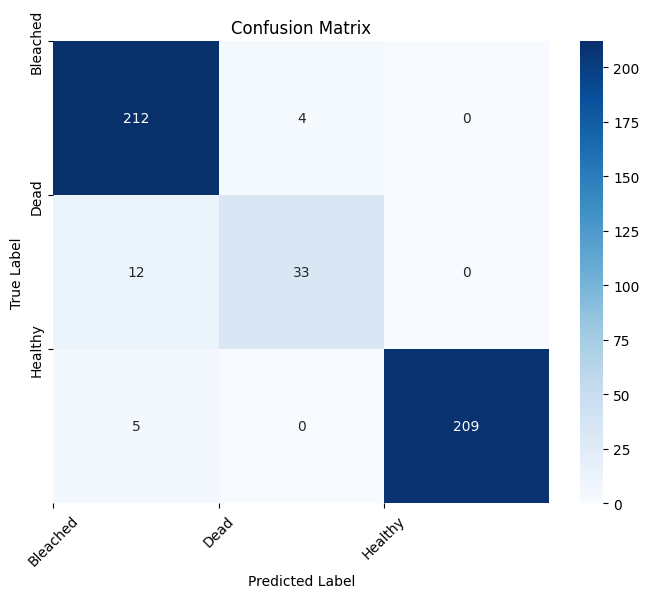

In [43]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")


plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step


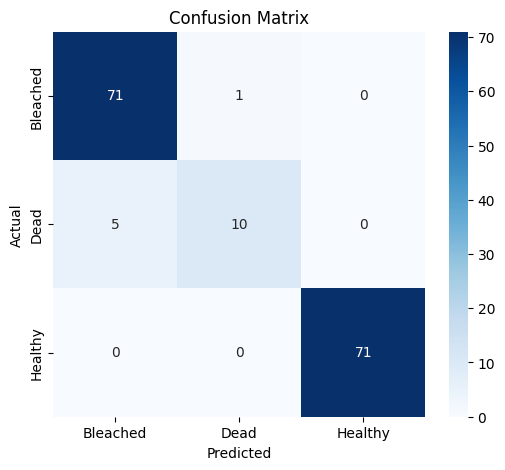

              precision    recall  f1-score   support

    Bleached       0.93      0.99      0.96        72
        Dead       0.91      0.67      0.77        15
     Healthy       1.00      1.00      1.00        71

    accuracy                           0.96       158
   macro avg       0.95      0.88      0.91       158
weighted avg       0.96      0.96      0.96       158



In [15]:
"""valid_data.reset()
import seaborn as sns
# Predict validation images
Y_pred = model.predict(valid_data)
y_pred = np.argmax(Y_pred, axis=1)

# Build confusion matrix
cm = confusion_matrix(valid_data.classes, y_pred)
class_names = list(valid_data.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Detailed metrics
print(classification_report(
    valid_data.classes,
    y_pred,
    target_names=class_names
))
"""

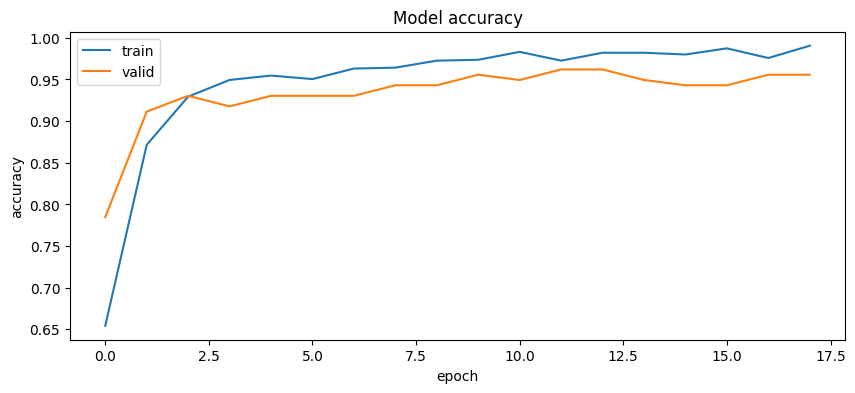

In [44]:
plt.figure( figsize = (10,4))  
plt.plot(history.history['accuracy']) 
plt.plot(history.history['val_accuracy'])  
plt.title('Model accuracy')  
plt.ylabel('accuracy')  
plt.xlabel('epoch')  
plt.legend(['train', 'valid'])

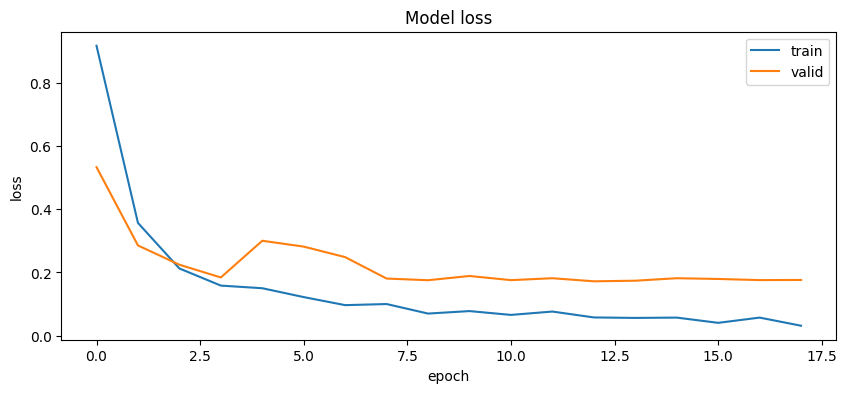

In [45]:
plt.figure(figsize = (10,4)) 
plt.plot(history.history['loss'])  
plt.plot(history.history['val_loss'])  
plt.title('Model loss')  
plt.ylabel('loss')  
plt.xlabel('epoch')  
plt.legend(['train', 'valid']) 
plt.show()

In [34]:
import matplotlib.pyplot as plt

def predict_and_show(img_path, model, class_labels):
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis("off")

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = np.max(predictions)

    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step


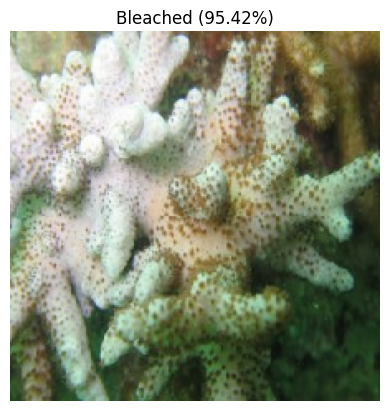

In [37]:
predict_and_show(r"C:\ml\testble.jpg", model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


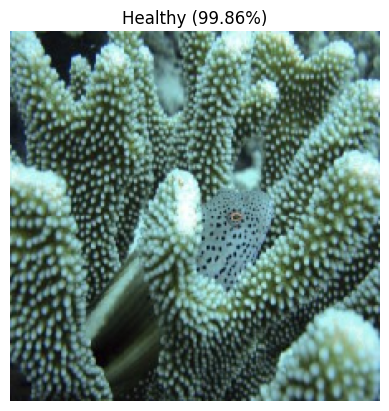

In [39]:
predict_and_show(r"C:\ml\testheal.jpg", model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


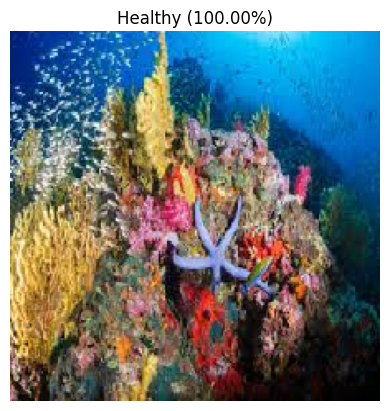

In [58]:
predict_and_show(r"C:\ml\download.jpg", model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


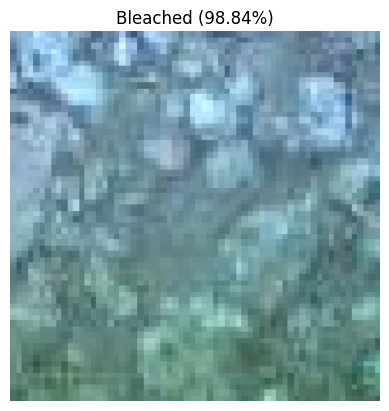

In [60]:
predict_and_show(r"C:\ml\deadds\total_dataset\dead_eilat_T264.jpg", model, class_labels)

In [47]:
model.save("ResNet152.keras")

In [42]:
from keras.models import load_model
saved_model = load_model("ResNet152.keras")

C:\Users\riajo\anaconda3\envs\myml\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 44 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:

]]